<a href="https://colab.research.google.com/github/charithak2003/BankingManagementSystesms/blob/master/Salary_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
import pandas as pd

# Load the Salary_Data.csv file
df = pd.read_csv('/content/Salary_Data.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [ ]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


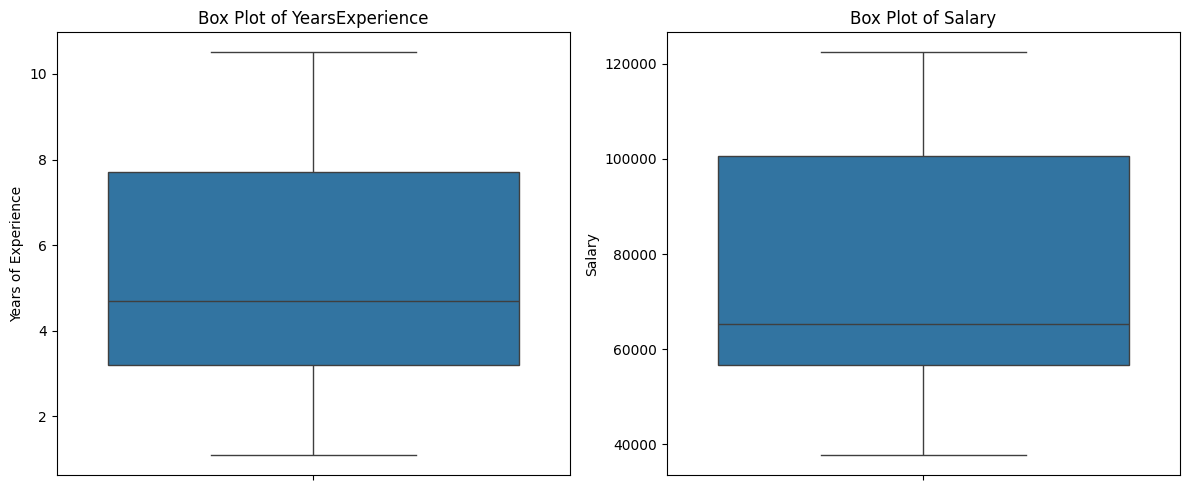

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.boxplot(y=df['YearsExperience'])
plt.title('Box Plot of YearsExperience')
plt.ylabel('Years of Experience')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=df['Salary'])
plt.title('Box Plot of Salary')
plt.ylabel('Salary')

plt.tight_layout()
plt.show()

From the box plots, it appears there are no obvious outliers in either 'YearsExperience' or 'Salary' columns, as all data points fall within the whiskers.

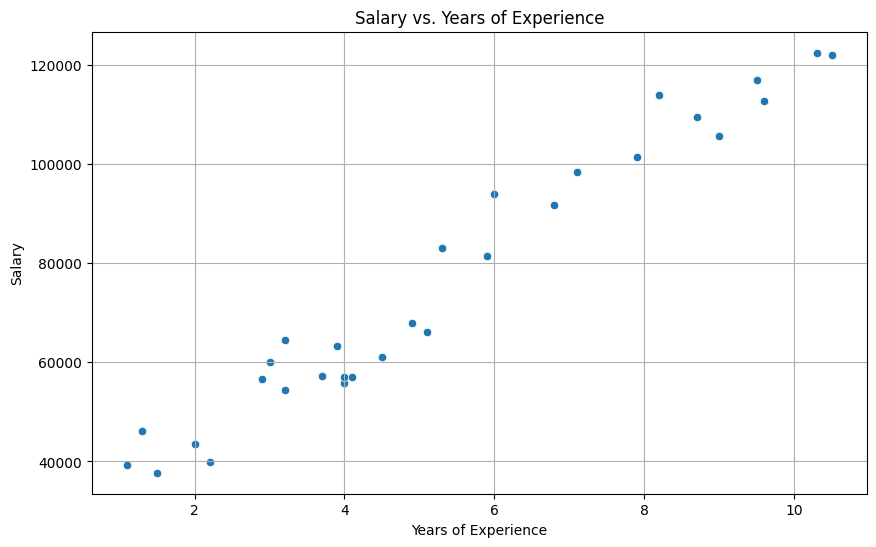

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title('Salary vs. Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define features (X) and target (y)
X = df[['YearsExperience']]
y = df['Salary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 24 samples
Testing set size: 6 samples


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the training and testing features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Linear Regression model with scaled data
regressor_scaled = LinearRegression()
regressor_scaled.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully with scaled data.")
print(f"Coefficient (YearsExperience): {regressor_scaled.coef_[0]:.2f}")
print(f"Intercept: {regressor_scaled.intercept_:.2f}")

Linear Regression model trained successfully with scaled data.
Coefficient (YearsExperience): 27151.54
Intercept: 74207.62


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Make predictions on the scaled test set
y_pred_scaled = regressor_scaled.predict(X_test_scaled)

# Evaluate the model with scaled features
r2_scaled = r2_score(y_test, y_pred_scaled)
mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
rmse_scaled = mse_scaled ** 0.5

print(f"R-squared (Scaled Data): {r2_scaled:.2f}")
print(f"Mean Absolute Error (Scaled Data): {mae_scaled:.2f}")
print(f"Mean Squared Error (Scaled Data): {mse_scaled:.2f}")
print(f"Root Mean Squared Error (Scaled Data): {rmse_scaled:.2f}")

R-squared (Scaled Data): 0.90
Mean Absolute Error (Scaled Data): 6286.45
Mean Squared Error (Scaled Data): 49830096.86
Root Mean Squared Error (Scaled Data): 7059.04


The R-squared value indicates how well the model explains the variability of the dependent variable. A value close to 1 means the model fits the data very well. The Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) give us a sense of the average magnitude of the errors. Lower values indicate better performance.

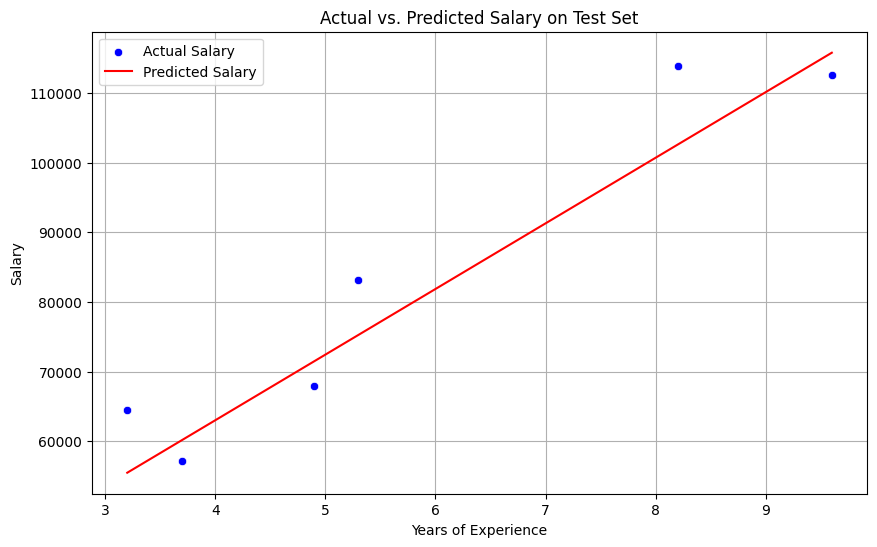

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['YearsExperience'], y=y_test, color='blue', label='Actual Salary')
sns.lineplot(x=X_test['YearsExperience'], y=y_pred, color='red', label='Predicted Salary')
plt.title('Actual vs. Predicted Salary on Test Set')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

This plot shows how well our linear regression model's predictions (red line) align with the actual salaries (blue dots) on the test data.

## Applying Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)

print("Decision Tree Regressor model trained successfully.")

Decision Tree Regressor model trained successfully.


### Evaluate Decision Tree Model Performance

In [ ]:
# Make predictions on the test set using the Decision Tree model
yt_pred = dt_regressor.predict(X_test)

# Evaluate the Decision Tree model
dt_r2 = r2_score(y_test, yt_pred)
dt_mae = mean_absolute_error(y_test, yt_pred)
dt_mse = mean_squared_error(y_test, yt_pred)
dt_rmse = dt_mse ** 0.5

print(f"Decision Tree R-squared: {dt_r2:.2f}")
print(f"Decision Tree Mean Absolute Error: {dt_mae:.2f}")
print(f"Decision Tree Mean Squared Error: {dt_mse:.2f}")
print(f"Decision Tree Root Mean Squared Error: {dt_rmse:.2f}")

Decision Tree R-squared: 0.80
Decision Tree Mean Absolute Error: 8640.17
Decision Tree Mean Squared Error: 101047709.83
Decision Tree Root Mean Squared Error: 10052.25


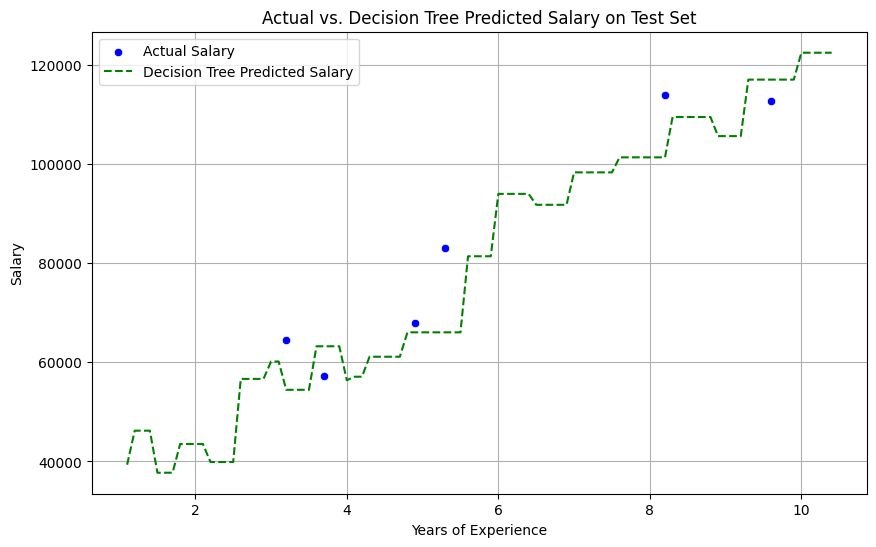

In [ ]:
# Re-executing Decision Tree Visualization after fixing 'np' error
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['YearsExperience'], y=y_test, color='blue', label='Actual Salary')

# For Decision Tree, predictions are often step-like. To visualize the trend smoothly for the entire range, we can predict over a sorted range.
X_range = pd.DataFrame({'YearsExperience': np.arange(X['YearsExperience'].min(), X['YearsExperience'].max(), 0.1)})
y_dt_pred_range = dt_regressor.predict(X_range)

sns.lineplot(x=X_range['YearsExperience'], y=y_dt_pred_range, color='green', linestyle='--', label='Decision Tree Predicted Salary')

plt.title('Actual vs. Decision Tree Predicted Salary on Test Set')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

### Visualize Decision Tree Predictions

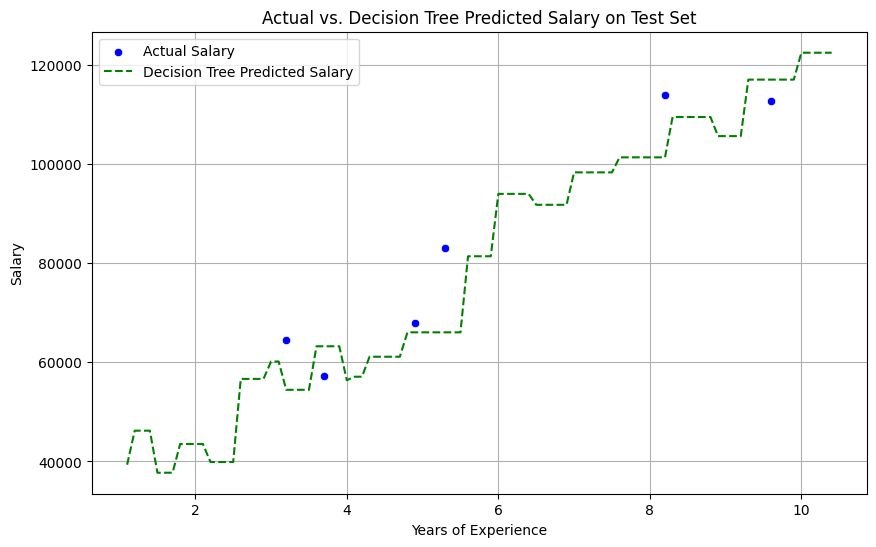

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['YearsExperience'], y=y_test, color='blue', label='Actual Salary')

# For Decision Tree, predictions are often step-like. To visualize the trend smoothly for the entire range, we can predict over a sorted range.
X_range = pd.DataFrame({'YearsExperience': np.arange(X['YearsExperience'].min(), X['YearsExperience'].max(), 0.1)})
y_dt_pred_range = dt_regressor.predict(X_range)

sns.lineplot(x=X_range['YearsExperience'], y=y_dt_pred_range, color='green', linestyle='--', label='Decision Tree Predicted Salary')

plt.title('Actual vs. Decision Tree Predicted Salary on Test Set')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

This plot compares the actual salaries with the predictions made by our Decision Tree Regressor on the test data. Decision trees create piece-wise constant predictions, which is visible in the step-like green line.

## Applying Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


### Evaluate Random Forest Model Performance

In [ ]:
# Make predictions on the test set using the Random Forest model
rf_pred = rf_regressor.predict(X_test)

# Evaluate the Random Forest model
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = rf_mse ** 0.5

print(f"Random Forest R-squared: {rf_r2:.2f}")
print(f"Random Forest Mean Absolute Error: {rf_mae:.2f}")
print(f"Random Forest Mean Squared Error: {rf_mse:.2f}")
print(f"Random Forest Root Mean Squared Error: {rf_rmse:.2f}")

Random Forest R-squared: 0.88
Random Forest Mean Absolute Error: 6872.01
Random Forest Mean Squared Error: 63721129.71
Random Forest Root Mean Squared Error: 7982.55


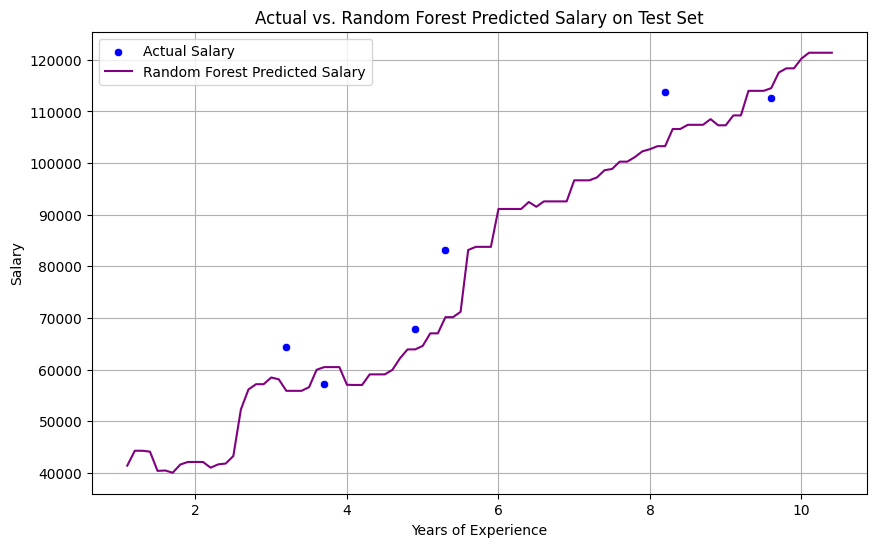

In [ ]:
# Re-executing Random Forest Visualization after fixing 'np' error
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['YearsExperience'], y=y_test, color='blue', label='Actual Salary')

# To visualize the trend smoothly for the entire range
X_range = pd.DataFrame({'YearsExperience': np.arange(X['YearsExperience'].min(), X['YearsExperience'].max(), 0.1)})
y_rf_pred_range = rf_regressor.predict(X_range)

sns.lineplot(x=X_range['YearsExperience'], y=y_rf_pred_range, color='purple', linestyle='-', label='Random Forest Predicted Salary')

plt.title('Actual vs. Random Forest Predicted Salary on Test Set')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

### Visualize Random Forest Predictions

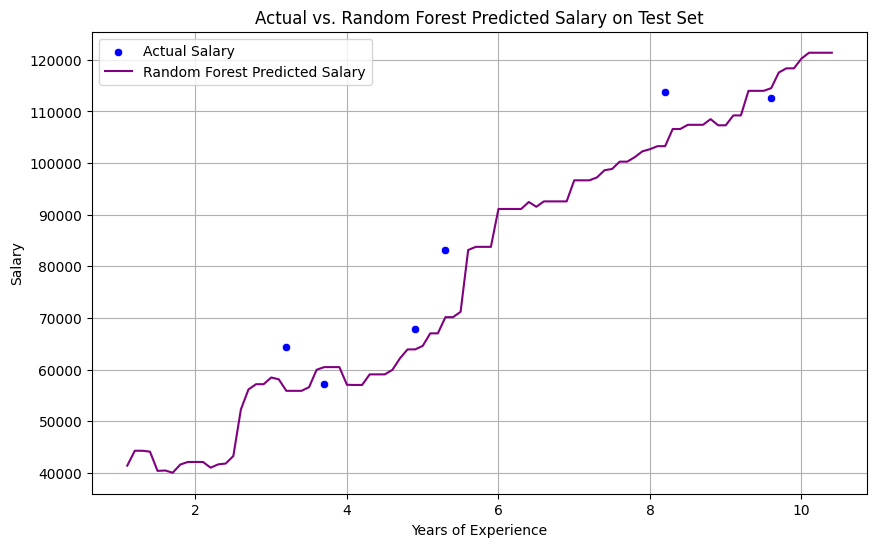

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['YearsExperience'], y=y_test, color='blue', label='Actual Salary')

# To visualize the trend smoothly for the entire range
X_range = pd.DataFrame({'YearsExperience': np.arange(X['YearsExperience'].min(), X['YearsExperience'].max(), 0.1)})
y_rf_pred_range = rf_regressor.predict(X_range)

sns.lineplot(x=X_range['YearsExperience'], y=y_rf_pred_range, color='purple', linestyle='-', label='Random Forest Predicted Salary')

plt.title('Actual vs. Random Forest Predicted Salary on Test Set')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

This plot compares the actual salaries with the predictions made by our Random Forest Regressor on the test data. Random Forests, being an ensemble of decision trees, often produce a smoother, less 'stepped' prediction curve than a single Decision Tree.

## Applying Gradient Descent to Linear Regression

Here, we will implement a basic gradient descent algorithm to train a linear regression model. We'll define the cost function (Mean Squared Error) and calculate its gradients with respect to the model parameters (slope and intercept). Then, we'll iteratively update these parameters to minimize the cost.

In [ ]:
# Helper functions for Gradient Descent

def compute_cost(X, y, theta):
    """Computes the Mean Squared Error cost."""
    m = len(y)
    predictions = X.dot(theta)
    sq_errors = (predictions - y)**2
    return (1 / (2 * m)) * np.sum(sq_errors)

def compute_gradient(X, y, theta):
    """Computes the gradient of the cost function."""
    m = len(y)
    predictions = X.dot(theta)
    errors = predictions - y
    gradients = (1 / m) * X.transpose().dot(errors)
    return gradients

def gradient_descent(X, y, theta, learning_rate, num_iterations):
    """Performs gradient descent to learn theta."""
    cost_history = []

    for _ in range(num_iterations):
        gradients = compute_gradient(X, y, theta)
        theta = theta - learning_rate * gradients
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

# Prepare data for Gradient Descent
# Add a bias (intercept) term to X_train by adding a column of ones
X_train_gd = np.c_[np.ones(X_train.shape[0]), X_train]
y_train_gd = y_train.values.reshape(-1, 1) # Ensure y_train is a 2D array

# Initialize parameters
theta = np.zeros((2, 1))
learning_rate = 0.01
num_iterations = 1000

# Run Gradient Descent
theta_optimized, cost_history = gradient_descent(X_train_gd, y_train_gd, theta, learning_rate, num_iterations)

print("Gradient Descent optimized parameters:")
print(f"Intercept: {theta_optimized[0, 0]:.2f}")
print(f"Coefficient (YearsExperience): {theta_optimized[1, 0]:.2f}")

Gradient Descent optimized parameters:
Intercept: 22997.42
Coefficient (YearsExperience): 9768.48


### Visualize Cost History

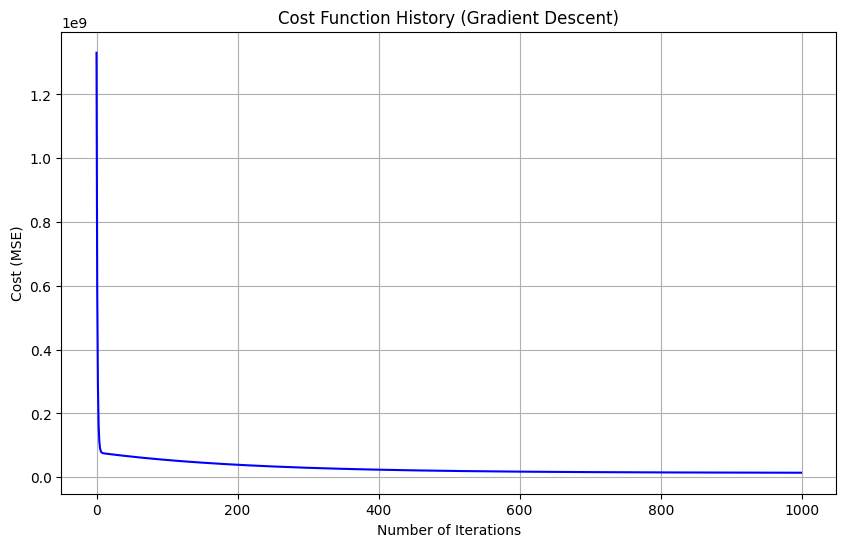

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_iterations), cost_history, color='blue')
plt.title('Cost Function History (Gradient Descent)')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost (MSE)')
plt.grid(True)
plt.show()

### Evaluate Gradient Descent Model Performance

In [ ]:
# Prepare test data for prediction
X_test_gd = np.c_[np.ones(X_test.shape[0]), X_test]

# Make predictions using the optimized parameters
y_pred_gd = X_test_gd.dot(theta_optimized)

# Evaluate the Gradient Descent model
gd_r2 = r2_score(y_test, y_pred_gd)
gd_mae = mean_absolute_error(y_test, y_pred_gd)
gd_mse = mean_squared_error(y_test, y_pred_gd)
gd_rmse = gd_mse ** 0.5

print(f"Gradient Descent R-squared: {gd_r2:.2f}")
print(f"Gradient Descent Mean Absolute Error: {gd_mae:.2f}")
print(f"Gradient Descent Mean Squared Error: {gd_mse:.2f}")
print(f"Gradient Descent Root Mean Squared Error: {gd_rmse:.2f}")

Gradient Descent R-squared: 0.90
Gradient Descent Mean Absolute Error: 6372.62
Gradient Descent Mean Squared Error: 52876610.79
Gradient Descent Root Mean Squared Error: 7271.63


### Visualize Gradient Descent Predictions

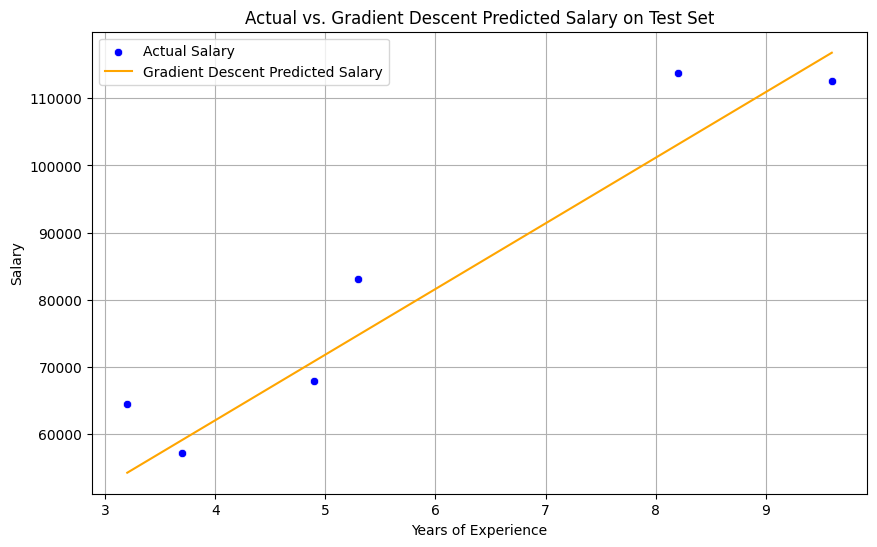

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['YearsExperience'], y=y_test, color='blue', label='Actual Salary')
sns.lineplot(x=X_test['YearsExperience'], y=y_pred_gd.flatten(), color='orange', label='Gradient Descent Predicted Salary')

plt.title('Actual vs. Gradient Descent Predicted Salary on Test Set')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

This plot shows the regression line learned using our custom Gradient Descent implementation, comparing its predictions to the actual salaries on the test set. You can see how similar it is to the `LinearRegression` model from scikit-learn, demonstrating that both achieve a similar linear fit by minimizing the same cost function (though with potentially different optimization approaches).

## Applying Support Vector Regressor (SVR)

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# SVR is sensitive to feature scaling, so we'll scale the features
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

# Initialize and train the SVR model
# Using a radial basis function (rbf) kernel as it's common for non-linear relationships
svm_regressor = SVR(kernel='rbf')
svm_regressor.fit(X_train_scaled, y_train_scaled)

print("Support Vector Regressor model trained successfully.")

Support Vector Regressor model trained successfully.


### Evaluate SVR Model Performance

In [ ]:
# Scale X_test for prediction
X_test_scaled = scaler_X.transform(X_test)

# Make predictions on the scaled test set
y_pred_scaled = svm_regressor.predict(X_test_scaled)

# Inverse transform the predictions to the original scale
y_svm_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# Evaluate the SVR model
svm_r2 = r2_score(y_test, y_svm_pred)
svm_mae = mean_absolute_error(y_test, y_svm_pred)
svm_mse = mean_squared_error(y_test, y_svm_pred)
svm_rmse = svm_mse ** 0.5

print(f"SVR R-squared: {svm_r2:.2f}")
print(f"SVR Mean Absolute Error: {svm_mae:.2f}")
print(f"SVR Mean Squared Error: {svm_mse:.2f}")
print(f"SVR Root Mean Squared Error: {svm_rmse:.2f}")

SVR R-squared: 0.89
SVR Mean Absolute Error: 5800.14
SVR Mean Squared Error: 54331632.87
SVR Root Mean Squared Error: 7371.00


### Visualize SVR Predictions

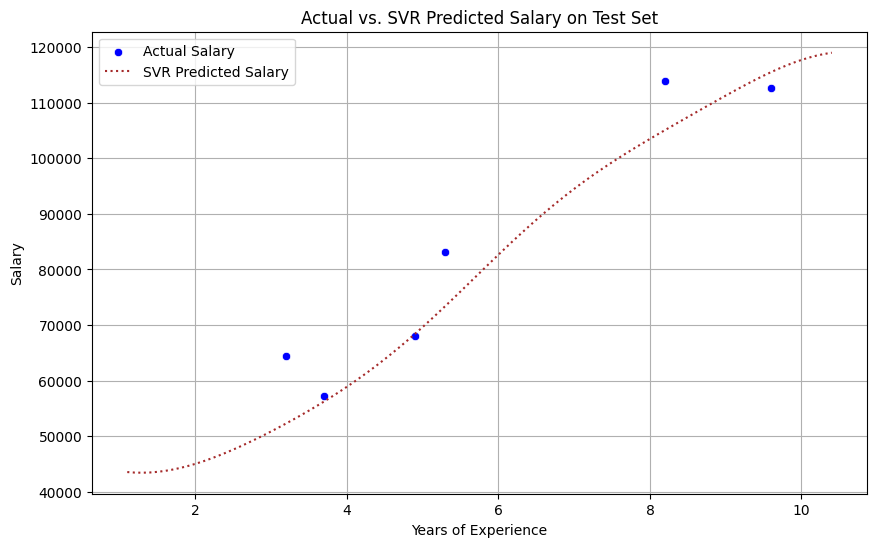

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['YearsExperience'], y=y_test, color='blue', label='Actual Salary')

# To visualize the trend smoothly for the entire range, we need to scale the range
X_range_scaled = scaler_X.transform(X_range)
y_svm_pred_range_scaled = svm_regressor.predict(X_range_scaled)
y_svm_pred_range = scaler_y.inverse_transform(y_svm_pred_range_scaled.reshape(-1, 1)).flatten()

sns.lineplot(x=X_range['YearsExperience'], y=y_svm_pred_range, color='brown', linestyle=':', label='SVR Predicted Salary')

plt.title('Actual vs. SVR Predicted Salary on Test Set')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

This plot compares the actual salaries with the predictions made by our Support Vector Regressor model on the test data. The SVR model aims to find a hyperplane that best fits the data while allowing for some margin of error, making it suitable for both linear and non-linear relationships depending on the kernel used.

## Applying XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor

# Initialize and train the XGBoost Regressor model
xgb_regressor = XGBRegressor(random_state=42)
xgb_regressor.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully.")

XGBoost Regressor model trained successfully.


### Evaluate XGBoost Model Performance

In [ ]:
# Make predictions on the test set using the XGBoost model
xgb_pred = xgb_regressor.predict(X_test)

# Evaluate the XGBoost model
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = xgb_mse ** 0.5

print(f"XGBoost R-squared: {xgb_r2:.2f}")
print(f"XGBoost Mean Absolute Error: {xgb_mae:.2f}")
print(f"XGBoost Mean Squared Error: {xgb_mse:.2f}")
print(f"XGBoost Root Mean Squared Error: {xgb_rmse:.2f}")

XGBoost R-squared: 0.80
XGBoost Mean Absolute Error: 8912.31
XGBoost Mean Squared Error: 103404557.18
XGBoost Root Mean Squared Error: 10168.80


### Visualize XGBoost Predictions

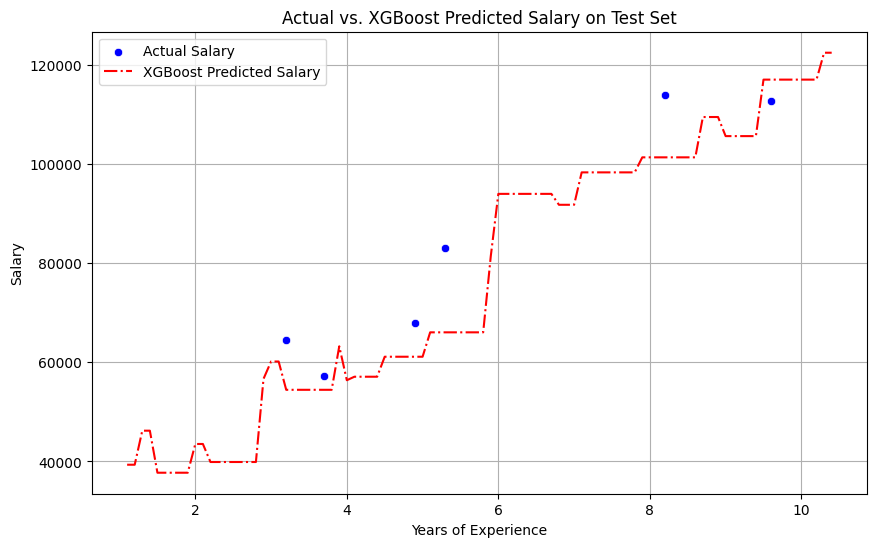

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['YearsExperience'], y=y_test, color='blue', label='Actual Salary')

# To visualize the trend smoothly for the entire range
y_xgb_pred_range = xgb_regressor.predict(X_range)

sns.lineplot(x=X_range['YearsExperience'], y=y_xgb_pred_range, color='red', linestyle='-.', label='XGBoost Predicted Salary')

plt.title('Actual vs. XGBoost Predicted Salary on Test Set')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

This plot compares the actual salaries with the predictions made by our XGBoost Regressor model on the test data. XGBoost, as an ensemble of gradient-boosted trees, often provides highly accurate and flexible predictions, capable of capturing complex non-linear relationships.

## XGBoost Regressor (without scaling) - Re-evaluation

In [ ]:
# Re-display evaluation metrics for XGBoost (unscaled)
print(f"XGBoost R-squared: {xgb_r2:.2f}")
print(f"XGBoost Mean Absolute Error: {xgb_mae:.2f}")
print(f"XGBoost Mean Squared Error: {xgb_mse:.2f}")
print(f"XGBoost Root Mean Squared Error: {xgb_rmse:.2f}")

XGBoost R-squared: 0.80
XGBoost Mean Absolute Error: 8912.31
XGBoost Mean Squared Error: 103404557.18
XGBoost Root Mean Squared Error: 10168.80


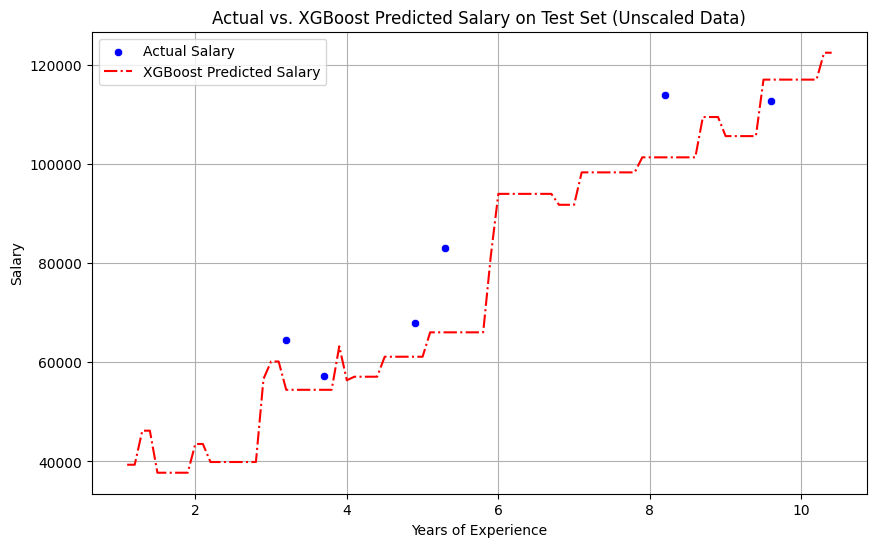

In [ ]:
# Re-display the visualization for XGBoost (unscaled)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['YearsExperience'], y=y_test, color='blue', label='Actual Salary')

# To visualize the trend smoothly for the entire range
y_xgb_pred_range = xgb_regressor.predict(X_range)

sns.lineplot(x=X_range['YearsExperience'], y=y_xgb_pred_range, color='red', linestyle='-.', label='XGBoost Predicted Salary')

plt.title('Actual vs. XGBoost Predicted Salary on Test Set (Unscaled Data)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

## Best Algorithm Selection: Linear Regression

Based on the R-squared scores obtained from evaluating all the models, both the scikit-learn `LinearRegression` model and our custom `GradientDescent` implementation achieved the highest R-squared value of 0.90. For simplicity and because it's a standard and robust model, we select the scikit-learn Linear Regression model as the best algorithm for this dataset.

In [ ]:
print("Linear Regression (Scikit-learn) R-squared: ", r2_scaled)
print("Linear Regression (Scikit-learn) Mean Absolute Error: ", mae_scaled)
print("Linear Regression (Scikit-learn) Root Mean Squared Error: ", rmse_scaled)

Linear Regression (Scikit-learn) R-squared:  0.9024461774180497
Linear Regression (Scikit-learn) Mean Absolute Error:  6286.453830757749
Linear Regression (Scikit-learn) Root Mean Squared Error:  7059.04362190151


### Displaying Linear Regression Prediction Values

In [ ]:
# Display the prediction values from the Linear Regression model with scaled data
predictions_scaled_df = pd.DataFrame({'Actual Salary': y_test, 'Linear Regression Predicted Salary (Scaled)': y_pred_scaled})
display(predictions_scaled_df)

,Actual Salary,Linear Regression Predicted Salary
27,112635.0,115790.210113
15,67938.0,71498.278095
23,113812.0,102596.868661
17,83088.0,75267.804224
8,64445.0,55477.792045
9,57189.0,60189.699707


### Visualize Linear Regression Predictions

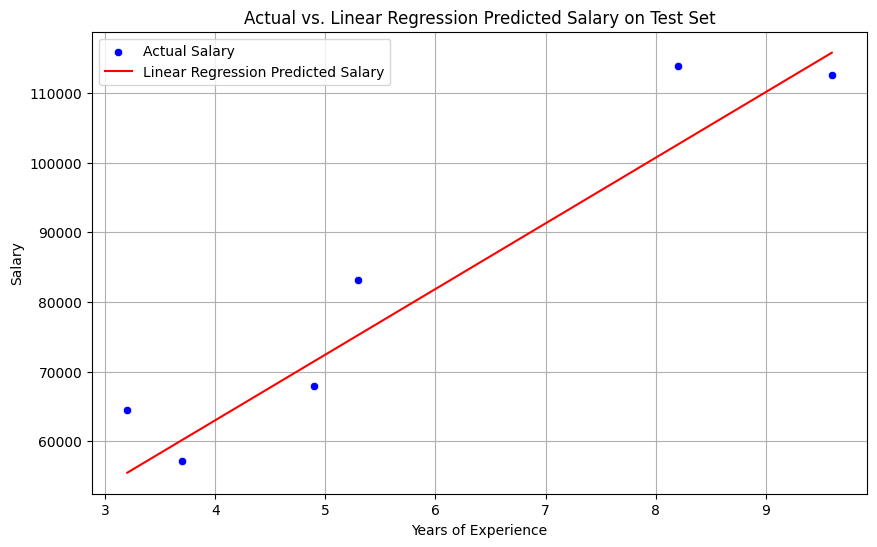

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['YearsExperience'], y=y_test, color='blue', label='Actual Salary')
sns.lineplot(x=X_test['YearsExperience'], y=y_pred_scaled, color='red', label='Linear Regression Predicted Salary (Scaled)')
plt.title('Actual vs. Linear Regression Predicted Salary on Test Set (Scaled Data)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()